In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Sakib
[nltk_data]     Malik\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
df=pd.read_csv('spam_ham_dataset.csv')
df.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [4]:
df.size

20684

In [5]:
df.isnull().sum()

Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.shape

(5171, 4)

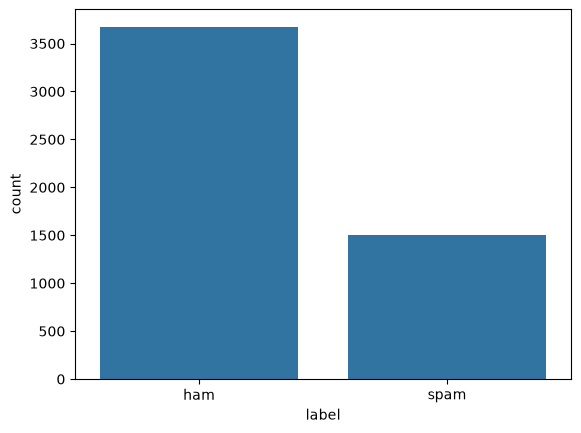

In [8]:
sns.countplot(x='label',data=df)
plt.show()

HAM SHAPE (3672, 4)
SPAM SHAPE (1499, 4)
HASM SHAPE (1499, 4)
HASM SHAPE (2998, 4)


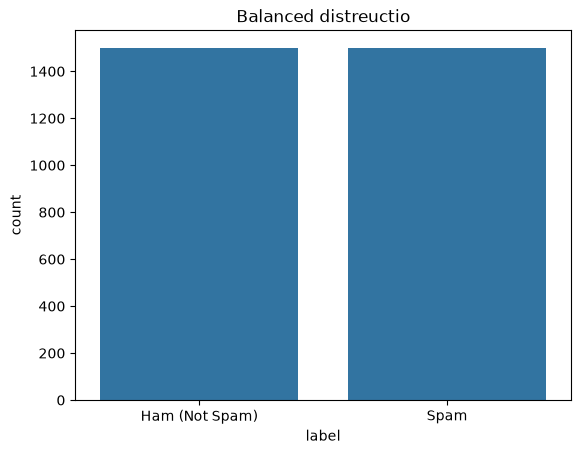

In [9]:
ham_msg=df[df['label']=='ham']
spam_msg=df[df['label']=='spam']
print("HAM SHAPE",ham_msg.shape)
print("SPAM SHAPE",spam_msg.shape)

ham_msg_balanced=ham_msg.sample(n=len(spam_msg),random_state=42)
print("HASM SHAPE",ham_msg_balanced.shape)
balanced_dataset=pd.concat([ham_msg_balanced,spam_msg]).reset_index(drop=True)
print("HASM SHAPE",balanced_dataset.shape)

sns.countplot(x='label',data=balanced_dataset)
plt.title("Balanced distreuctio")
plt.xticks(ticks=[0, 1], labels=['Ham (Not Spam)', 'Spam'])
plt.show()


In [10]:
balanced_dataset['text']=balanced_dataset['text'].str.replace('Subject','')
balanced_dataset.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,: conoco - big cowboy\r\ndarren :\r\ni ' m not...,0
1,2982,ham,: feb 01 prod : sale to teco gas processing\r\...,0
2,2711,ham,": california energy crisis\r\ncalifornia  , s...",0
3,3116,ham,: re : nom / actual volume for april 23 rd\r\n...,0
4,1314,ham,: eastrans nomination changes effective 8 / 2 ...,0


In [11]:
punctuations_list=string.punctuation

def remove_punctuation(text):
    temp=str.maketrans('','',punctuations_list)
    return text.translate(temp)


balanced_dataset['text']=balanced_dataset['text'].apply(lambda x: remove_punctuation(x))
balanced_dataset.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy\r\ndarren \r\ni m not sur...,0
1,2982,ham,feb 01 prod sale to teco gas processing\r\ns...,0
2,2711,ham,california energy crisis\r\ncalifornia  s p...,0
3,3116,ham,re nom actual volume for april 23 rd\r\nwe ...,0
4,1314,ham,eastrans nomination changes effective 8 2 0...,0


In [12]:
def remove_stopwords(text):
    stop_words=stopwords.words('english')
    imp_words=[]
    for word in str(text).split():
        word =word.lower()
        if word not in stop_words:
            imp_words.append(word)
    output=" ".join(imp_words)
    return output


balanced_dataset['text']=balanced_dataset['text'].map(remove_stopwords)
balanced_dataset.head() 

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy darren sure help know else a...,0
1,2982,ham,feb 01 prod sale teco gas processing sale deal...,0
2,2711,ham,california energy crisis california  power cr...,0
3,3116,ham,nom actual volume april 23 rd agree eileen pon...,0
4,1314,ham,eastrans nomination changes effective 8 2 00 p...,0


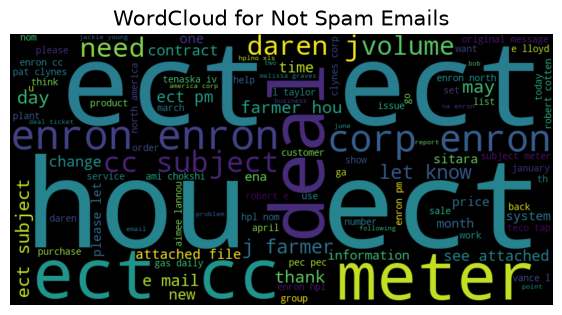

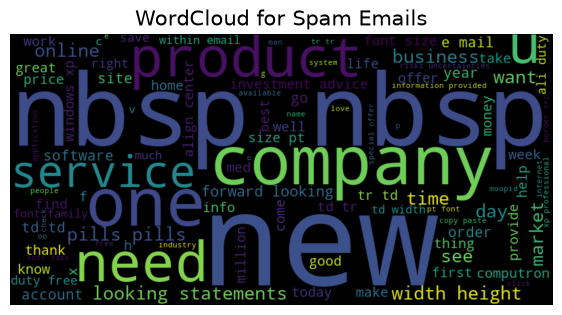

In [13]:
def plot_word_cloud(data,typ):
    email_corpus=" ".join(data['text'])
    wc=WordCloud(background_color="black",max_words=100,width=800,height=400).generate(email_corpus)
    plt.figure(figsize=(7, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'WordCloud for {typ} Emails', fontsize=15)
    plt.axis('off')
    plt.show()

plot_word_cloud(balanced_dataset[balanced_dataset['label']=='ham'],typ="Not Spam")
plot_word_cloud(balanced_dataset[balanced_dataset['label']=='spam'],typ="Spam")

In [14]:
balanced_dataset=balanced_dataset.drop(columns=["Unnamed: 0","label_num"])
balanced_dataset

,label,text
0,ham,conoco big cowboy darren sure help know else a...
1,ham,feb 01 prod sale teco gas processing sale deal...
2,ham,california energy crisis california  power cr...
3,ham,nom actual volume april 23 rd agree eileen pon...
4,ham,eastrans nomination changes effective 8 2 00 p...
...,...,...
2993,spam,pictures streamlined denizen ajar chased heave...
2994,spam,penny stocks timing nomad international inc nd...
2995,spam,anomaly boys 3881 uosda apaproved mledms heure...
2996,spam,slutty milf wants meet take ilaa liqaa


## CONVERT label to int

In [27]:
balanced_dataset['label']=balanced_dataset['label'].map({'ham':0,'spam':1})

## SAVE CLEANED Dataframe

In [28]:
balanced_dataset.to_csv('cleaned_data.csv',index=False)
balanced_dataset

,label,text
0,0,conoco big cowboy darren sure help know else a...
1,0,feb 01 prod sale teco gas processing sale deal...
2,0,california energy crisis california  power cr...
3,0,nom actual volume april 23 rd agree eileen pon...
4,0,eastrans nomination changes effective 8 2 00 p...
...,...,...
2993,1,pictures streamlined denizen ajar chased heave...
2994,1,penny stocks timing nomad international inc nd...
2995,1,anomaly boys 3881 uosda apaproved mledms heure...
2996,1,slutty milf wants meet take ilaa liqaa


In [29]:
df=pd.read_csv("cleaned_data.csv")
df.head()

,label,text
0,0,conoco big cowboy darren sure help know else a...
1,0,feb 01 prod sale teco gas processing sale deal...
2,0,california energy crisis california  power cr...
3,0,nom actual volume april 23 rd agree eileen pon...
4,0,eastrans nomination changes effective 8 2 00 p...
